# brazilian company


In [26]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score,accuracy_score
import torch.nn as nn
import torch.nn.init as init
import torch.nn.functional as F
import math

In [27]:
!ls /kaggle/input/churn-model/pytorch/default/1/

'best_model (1).pth'  'scaler (1).pkl'


In [28]:
import joblib

scaler = joblib.load('/kaggle/input/churn-model/pytorch/default/1/scaler (1).pkl')


In [29]:
df = pd.read_csv("/kaggle/input/cleaned-brazilian-ecommerce-data/brazilian_ecommerce_cleaned.csv")
df.head()

,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,geolocation_city_customer,geolocation_state_customer,product_id,...,payment_type,payment_value,customer_unique_id,customer_zip_code_prefix,geolocation_lat_customer,geolocation_lng_customer,seller_id,seller_zip_code_prefix,geolocation_lat_seller,geolocation_lng_seller
0,00010242fe8c5a6d1ba2dd792cb16214,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29 00:00:00,campos dos goytacazes,RJ,4244733e06e7ecb4970a6e2683c13e61,...,credit_card,72.19,871766c5855e863f6eccc05f988b23cb,28013,-21.758076,-41.312633,48436dade18ac8b2bce089ec2a041202,27277,-22.498183,-44.123614
1,00018f77f2f0320c557190d7a144bdd3,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15 00:00:00,santa fe do sul,SP,e5f2d52b802189ee658865ca93d83a8f,...,credit_card,259.83,eb28e67c4c0b83846050ddfb8a35d051,15775,-20.212393,-50.941471,dd7ddc04e1b6c2c614352b383efe2d36,3471,-23.566258,-46.518417
2,000229ec398224ef6ca0657da4fc703e,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05 00:00:00,pará de minas,MG,c777355d18b72b67abbeef9df44fd0fd,...,credit_card,216.87,3818d81c6709e39d06b2738a8d3a2474,35661,-19.860439,-44.597972,5b51032eddd242adc84c38acab88f23d,37564,-22.264094,-46.158564
3,00024acbcdf0a6daa1e931b038114c75,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20 00:00:00,atibaia,SP,7634da152a4610f1595efa32f14722fc,...,credit_card,25.78,af861d436cfc08b2c2ddefd0ba074622,12952,-23.144923,-46.539830,9d7a1d34a5052409006425275ba1c2b4,14403,-20.548228,-47.395897
4,00042b26cf59d7ce69dfabb4e55b4fd9,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17 00:00:00,varzea paulista,SP,ac6c3623068f30de03045865e4e10089,...,credit_card,218.04,64b576fb70d441e8f1b2d7d446e483c5,13226,-23.249008,-46.824961,df560393f3a51e74553ab94004ba5c87,87900,-22.931427,-53.133759


In [30]:
df['Customer Name'] =df['customer_unique_id']

In [31]:
df['Quantity'] = 1

In [32]:
df['Age'] = 44
df['Customer Age'] = 44

In [33]:
df['Returns'] = 0

In [34]:
df['Gender'] = 0

In [35]:
df.count()

order_id                         112345
order_status                     112345
order_purchase_timestamp         112345
order_approved_at                112345
order_delivered_carrier_date     112345
order_delivered_customer_date    112345
order_estimated_delivery_date    112345
geolocation_city_customer        112345
geolocation_state_customer       112345
product_id                       112345
price                            112345
freight_value                    112345
shipping_limit_date              112345
product_category_name_english    112345
payment_type                     112345
payment_value                    112345
customer_unique_id               112345
customer_zip_code_prefix         112345
geolocation_lat_customer         112345
geolocation_lng_customer         112345
seller_id                        112345
seller_zip_code_prefix           112345
geolocation_lat_seller           112345
geolocation_lng_seller           112345
Customer Name                    112345


In [36]:
# Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
#        'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
#        'Returns', 'Customer Name', 'Age', 'Gender', 'Churn'],
#       dtype='object')


In [37]:
df = df.rename(columns={'customer_unique_id': 'Customer ID',
                        'order_purchase_timestamp':'Purchase Date',
                        'product_category_name_english':'Product Category',
                        'price':'Product Price',
                        'payment_value':'Total Purchase Amount',
                        'payment_type':'Payment Method',
                       })


In [38]:
df.count()

order_id                         112345
order_status                     112345
Purchase Date                    112345
order_approved_at                112345
order_delivered_carrier_date     112345
order_delivered_customer_date    112345
order_estimated_delivery_date    112345
geolocation_city_customer        112345
geolocation_state_customer       112345
product_id                       112345
Product Price                    112345
freight_value                    112345
shipping_limit_date              112345
Product Category                 112345
Payment Method                   112345
Total Purchase Amount            112345
Customer ID                      112345
customer_zip_code_prefix         112345
geolocation_lat_customer         112345
geolocation_lng_customer         112345
seller_id                        112345
seller_zip_code_prefix           112345
geolocation_lat_seller           112345
geolocation_lng_seller           112345
Customer Name                    112345


In [39]:
data = pd.read_csv("/kaggle/input/e-commerce-customer-for-behavior-analysis/ecommerce_customer_data_large.csv")


In [40]:
x = df.columns
y = data.columns
z = []
for i in x:
    if i not in y:
        z.append(i)

In [41]:
df= df.drop(columns = z)

In [42]:
df.count()

Purchase Date            112345
Product Price            112345
Product Category         112345
Payment Method           112345
Total Purchase Amount    112345
Customer ID              112345
Customer Name            112345
Quantity                 112345
Age                      112345
Customer Age             112345
Returns                  112345
Gender                   112345
dtype: int64

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112345 entries, 0 to 112344
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Purchase Date          112345 non-null  object 
 1   Product Price          112345 non-null  float64
 2   Product Category       112345 non-null  object 
 3   Payment Method         112345 non-null  object 
 4   Total Purchase Amount  112345 non-null  float64
 5   Customer ID            112345 non-null  object 
 6   Customer Name          112345 non-null  object 
 7   Quantity               112345 non-null  int64  
 8   Age                    112345 non-null  int64  
 9   Customer Age           112345 non-null  int64  
 10  Returns                112345 non-null  int64  
 11  Gender                 112345 non-null  int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 10.3+ MB


In [44]:
df['Purchase Date'].describe()

count                  112345
unique                  97841
top       2017-07-16 18:19:25
freq                       21
Name: Purchase Date, dtype: object

In [45]:
df['Purchase Date'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 112345 entries, 0 to 112344
Series name: Purchase Date
Non-Null Count   Dtype 
--------------   ----- 
112345 non-null  object
dtypes: object(1)
memory usage: 877.8+ KB


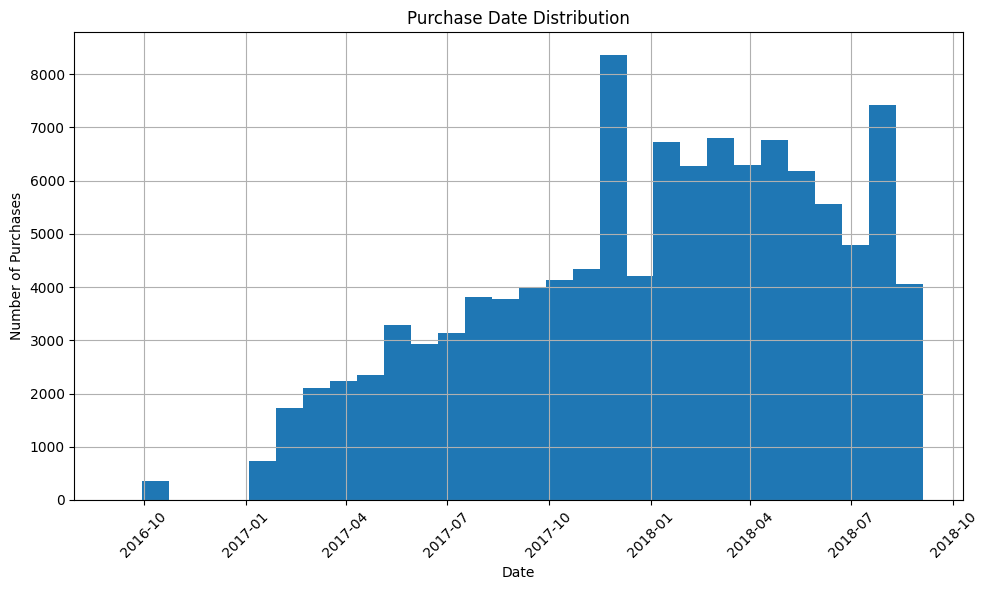

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure 'Purchase Date' is in datetime format
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

# Optional: Sort the dates (not strictly necessary for plotting)
df = df.sort_values('Purchase Date')

# Plot date distribution as a histogram
plt.figure(figsize=(10, 6))
df['Purchase Date'].hist(bins=30)  # You can adjust number of bins
plt.title('Purchase Date Distribution')
plt.xlabel('Date')
plt.ylabel('Number of Purchases')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [47]:
df['Customer ID'].nunique()

95155

In [59]:
# Convert 'Purchase Date' to datetime
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

# Set the churn cutoff date
churn_cutoff = pd.to_datetime('2018-07-01')

# Group by Customer ID and get the latest purchase date for each
last_purchase = df.groupby('Customer ID')['Purchase Date'].max()

# Determine which customers churned
churned_customers = last_purchase[last_purchase <= churn_cutoff].index

# Create a new column 'churned' in the original DataFrame
df['Churn'] = df['Customer ID'].isin(churned_customers).astype(int)


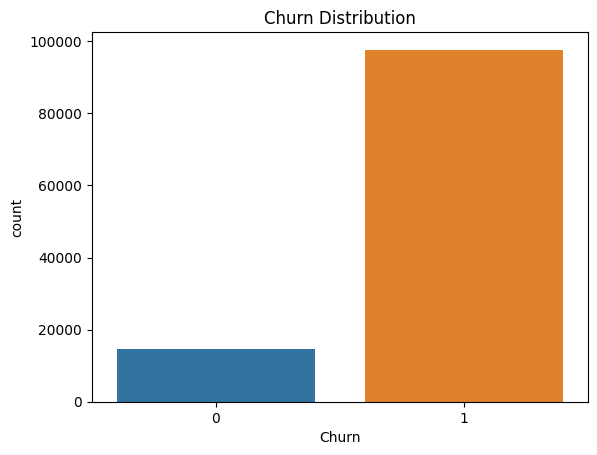

Churn
1    86.903734
0    13.096266
Name: count, dtype: float64


In [60]:
sns.countplot(x=df['Churn'])
plt.title('Churn Distribution')
plt.show()

print(((df['Churn'].value_counts())/len(df))*100)


In [61]:
df.count()

Purchase Date            112345
Product Price            112345
Product Category         112345
Payment Method           112345
Total Purchase Amount    112345
Customer ID              112345
Customer Name            112345
Quantity                 112345
Age                      112345
Customer Age             112345
Returns                  112345
Gender                   112345
Churn                    112345
dtype: int64

In [62]:
data['Product Category'].unique()

array(['Home', 'Electronics', 'Books', 'Clothing'], dtype=object)

In [63]:
df['Product Category'].unique()

array(['furniture_decor', 'telephony', 'baby', 'watches_gifts',
       'sports_leisure', 'fashion_shoes', 'toys', 'bed_bath_table',
       'consoles_games', 'housewares', 'fixed_telephony',
       'air_conditioning', 'auto', 'computers_accessories', 'perfumery',
       'health_beauty', 'cool_stuff', 'office_furniture', 'garden_tools',
       'fashion_male_clothing', 'industry_commerce_and_business',
       'market_place', 'electronics', 'fashio_female_clothing',
       'books_technical', 'pet_shop', 'fashion_bags_accessories', 'audio',
       'diapers_and_hygiene', 'books_general_interest', 'food',
       'furniture_bedroom', 'music', 'stationery', 'small_appliances',
       'home_appliances_2', 'fashion_underwear_beach',
       'agro_industry_and_commerce', 'home_comfort_2',
       'kitchen_dining_laundry_garden_furniture', 'security_and_services',
       'luggage_accessories', 'furniture_living_room',
       'musical_instruments', 'computers',
       'construction_tools_construction'

In [64]:
# Mapping categories
category_map = {
    'Home': [
        'furniture_decor', 'garden_tools', 'housewares', 'bed_bath_table',
        'office_furniture', 'home_appliances', 'kitchen_dining_laundry_garden_furniture',
        'air_conditioning', 'home_confort', 'small_appliances_home_oven_and_coffee',
        'diapers_and_hygiene', 'signaling_and_security', 'small_appliances',
        'costruction_tools_garden', 'home_construction', 'party_supplies',
        'construction_tools_safety', 'flowers', 'home_appliances_2',
        'furniture_living_room', 'furniture_bedroom', 'home_comfort_2',
        'christmas_supplies', 'furniture_mattress_and_upholstery',
        'costruction_tools_tools', 'la_cuisine',
        'baby', 'sports_leisure', 'toys', 'auto',
        'cool_stuff', 'industry_commerce_and_business',
        'market_place', 'pet_shop', 'food', 'stationery',
        'agro_industry_and_commerce', 'security_and_services',
        'drinks', 'food_drink'
        
    ],
    'Electronics': [
        'electronics', 'computers_accessories', 'telephony', 'consoles_games',
        'audio', 'fixed_telephony', 'cine_photo', 'computers',
        'tablets_printing_image', 'music', 'dvds_blu_ray', 'cds_dvds_musicals',
        'construction_tools_construction','construction_tools_lights'
    
    ],
    'Books': [
        'books_technical', 'books_general_interest', 'books_imported',
        'arts_and_craftmanship','musical_instruments','art'
    ],
    'Clothing': [
        'fashion_bags_accessories', 'fashion_underwear_beach',
        'fashion_male_clothing', 'fashion_shoes', 'fashio_female_clothing',
        'fashion_sport', 'fashion_childrens_clothes','perfumery','watches_gifts',
        'luggage_accessories','health_beauty'
    ]
}

# Flatten the mapping: specific → general
flat_map = {cat: broad for broad, items in category_map.items() for cat in items}

unmapped = df[~df['Product Category'].isin(flat_map.keys())]['Product Category'].unique()
print(unmapped)

# Replace values in the 'category' column
df['Product Category'] = df['Product Category'].map(flat_map)



[]


In [65]:
df['Product Category'].value_counts()


Product Category
Home           69272
Clothing       22730
Electronics    18552
Books           1791
Name: count, dtype: int64

In [66]:
df['Product Category'].isnull().sum()

0

In [67]:
df['Payment Method'].unique()


array(['credit_card', 'boleto', 'debit_card', 'voucher'], dtype=object)

In [68]:
data['Payment Method'].unique()


array(['PayPal', 'Credit Card', 'Cash'], dtype=object)

In [69]:
payment_map = {
    'credit_card': 'Credit Card',
    'debit_card': 'Credit Card',
    'voucher': 'Cash',
    'boleto': 'PayPal'
}

df['Payment Method'].map(payment_map)



20214     Credit Card
20213     Credit Card
101120    Credit Card
49685     Credit Card
26052          PayPal
             ...     
4910      Credit Card
9806             Cash
1718      Credit Card
23470     Credit Card
36984            Cash
Name: Payment Method, Length: 112345, dtype: object

In [70]:
df['Payment Method'].value_counts()

Payment Method
credit_card    85782
boleto         22806
voucher         2069
debit_card      1688
Name: count, dtype: int64

In [71]:
df['Payment Method'].isnull().sum()

0

In [72]:
df['Customer ID'] = df['Customer ID'].apply(lambda x: int(x, 16))

In [73]:
# df.to_csv('proessed_brazilian_data.csv', index=False)

In [74]:
df['Customer ID']

20214     244367299473992130996948086059495816471
20213     244367299473992130996948086059495816471
101120     96145308694827618774778664983284973202
49685      19533068194985247649868635720348087164
26052      67677611572652065312185842024554259951
                           ...                   
4910      122750409281984236908515637261358249619
9806      170035707358550985047422533757895197496
1718      243257784068090891343584582064491864353
23470      48746160372168372840154085124542601066
36984     339134281865845529031853810911933953380
Name: Customer ID, Length: 112345, dtype: object

In [75]:
# --- Test on proessed_brazilian_data.csv (unseen data) ---
import pandas as pd
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader

# 1. Load new data
new_data = df 

# 2. Preprocess (must match training pipeline)
new_data['Purchase Date'] = pd.to_datetime(new_data['Purchase Date'])
new_data['Year'] = new_data['Purchase Date'].dt.year
new_data['Month'] = new_data['Purchase Date'].dt.month
new_data['Day'] = new_data['Purchase Date'].dt.day

# One-hot encoding (must match training: drop_first=True)
new_data = pd.get_dummies(new_data, columns=['Gender', 'Payment Method', 'Product Category'], drop_first=True)

# Fill missing values in Returns
if new_data['Returns'].isnull().any():
    new_data['Returns'].fillna(new_data['Returns'].mode()[0], inplace=True)

# Features (must match training)
numerical_cols = [
    'Product Price', 'Quantity', 'Total Purchase Amount', 'Returns', 'Age', 'Year', 'Month', 'Day',
    'Gender_Male', 'Payment Method_Credit Card', 'Payment Method_PayPal',
    'Product Category_Clothing', 'Product Category_Electronics', 'Product Category_Home'
]

# Ensure all expected columns exist (add missing as zeros)
for col in numerical_cols:
    if col not in new_data.columns:
        new_data[col] = 0

# 3. Create sequences per customer
seq_length = 10
features = numerical_cols
sequences = []
labels = []
customer_ids = new_data['Customer ID'].unique()
for cid in customer_ids:
    customer_data = new_data[new_data['Customer ID'] == cid].sort_values(by='Purchase Date')
    for i in range(max(1, len(customer_data) - seq_length + 1)):
        seq = customer_data.iloc[i:min(i + seq_length, len(customer_data))][features].values
        if len(seq) < seq_length:
            pad_shape = (seq_length - len(seq), len(features))
            padding = np.zeros(pad_shape)
            seq = np.vstack([seq, padding])
        label = customer_data.iloc[min(i + seq_length - 1, len(customer_data) - 1)]['Churn']
        sequences.append(seq)
        labels.append(label)

X_new = np.array(sequences)
y_new = np.array(labels)



In [76]:

# 4. Reshape and scale (use the same scaler as training!)
X_new_reshaped = X_new.reshape(X_new.shape[0], -1)
X_new_scaled = scaler.transform(X_new_reshaped)  # scaler from training
X_new_scaled = X_new_scaled.reshape(-1, seq_length, len(features))


In [77]:
np.save("X_new_scaled.npy", X_new_scaled)
np.save("Y_new.npy", y_new)

# run from here if there is no changes on data

In [78]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=10000):
        super(PositionalEncoding, self).__init__()
        
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)
        
    def forward(self, x):
        # x shape: (batch_size, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]
        return x


class TransformerLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super(TransformerLayer, self).__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        
        self.self_attn = nn.MultiheadAttention(d_model, num_heads, dropout=dropout)
        
        # Feed-forward network
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        
    def forward(self, src):
        # src shape: (seq_len, batch_size, d_model)
        
        # Self-attention with residual connection
        src2 = self.norm1(src)
        attn_output, _ = self.self_attn(src2, src2, src2)
        src = src + (attn_output)
        
        # Feed-forward with residual connection
        src2 = self.norm2(src)
        src2 = self.linear2((F.relu(self.linear1(src2))))
        src = src + (src2)
        
        return src

class TransformerModel(nn.Module):
    def __init__(self, input_size, d_model, num_heads, d_ff, num_layers, output_size):
        super(TransformerModel, self).__init__()
        
        # Project input to model dimension
        self.embedding = nn.Linear(input_size, d_model)
        
        # Positional encoding
        self.pos_encoder = PositionalEncoding(d_model)
        
        # Transformer layers
        self.transformer_layers = nn.ModuleList([
            TransformerLayer(d_model, num_heads, d_ff) 
            for _ in range(num_layers)
        ])
        
        # Output layer
        self.fc = nn.Linear(d_model, d_model//2)
        self.output_layer = nn.Linear(d_model//2, output_size)
        
    def forward(self, x):
        # x shape: (batch_size, seq_len, input_size)
        
        # Reorder to (seq_len, batch_size, input_size)
        x = x.transpose(0, 1)
        
        # Project to d_model
        x = self.embedding(x)
        
        # Add positional encoding
        x = self.pos_encoder(x)
        
        # Pass through transformer layers
        for layer in self.transformer_layers:
            x = layer(x)
        
        # Get last time step (many-to-one)
        x = x[-1, :, :]  # (batch_size, d_model)
        
        # Output layer
        x=self.fc(x)
        output = self.output_layer(x)
        return torch.sigmoid(output)

print("ok")


ok


In [79]:
# Hyperparameters
input_size = 14  
d_model = 128
num_heads = 8
d_ff = 218
num_layers = 2
output_size = 1
batch_size = 128
learning_rate = 0.00001
num_epochs = 400
dropout = 0.1
patience = 15

# Initialize model, loss, and optimizer
# del model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TransformerModel(input_size, d_model, num_heads, d_ff, num_layers, output_size).to(device)
model.load_state_dict(torch.load('/kaggle/input/churn-model/pytorch/default/1/best_model (1).pth',map_location=device))


<All keys matched successfully>

In [80]:
# X_new_scaled = np.load("/kaggle/input/processed-brazilia-ecommerce-data/X_new_scaled.npy")
# X_new = X_new_scaled

In [81]:

# # 4. Reshape and scale (use the same scaler as training!)
# X_new_reshaped = X_new.reshape(X_new.shape[0], -1)
# X_new_scaled = scaler.transform(X_new_reshaped)  # scaler from training
# X_new_scaled = X_new_scaled.reshape(-1, seq_length, len(features))

# 5. Convert to tensor
X_new_tensor = torch.tensor(X_new_scaled, dtype=torch.float32)
y_new_tensor = torch.tensor(y_new, dtype=torch.float32)

# 6. Create DataLoader
new_dataset = TensorDataset(X_new_tensor, y_new_tensor)
new_loader = DataLoader(new_dataset, batch_size=128, shuffle=False)


In [82]:
# Evaluate on test set
def evaluate_model(model, new_loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    all_preds = []
    all_probs = []
    all_targets = []
    
    with torch.no_grad():
        for data, target in new_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            probs = torch.sigmoid(output).squeeze()

            # Store predictions and probabilities
            preds = (probs >= 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_targets.extend(target.cpu().numpy())
    
    # Calculate metrics
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)
    all_targets = np.array(all_targets)
    
    accuracy = accuracy_score(all_targets, all_preds)
    precision = precision_score(all_targets, all_preds)
    recall = recall_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds)
    roc_auc = roc_auc_score(all_targets, all_probs)
    
    print('\nTest Set Evaluation:')
    print(f'Accuracy: {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1 Score: {f1:.4f}')
    print(f'ROC AUC: {roc_auc:.4f}')


In [83]:
# 8. Evaluate
evaluate_model(model, new_loader)


Test Set Evaluation:
Accuracy: 0.8681
Precision: 0.8681
Recall: 1.0000
F1 Score: 0.9294
ROC AUC: 0.4926



📊 Evaluation Metrics:
Accuracy : 0.7282
Precision: 0.8645
Recall   : 0.8146
F1 Score : 0.8388
ROC AUC  : 0.4936


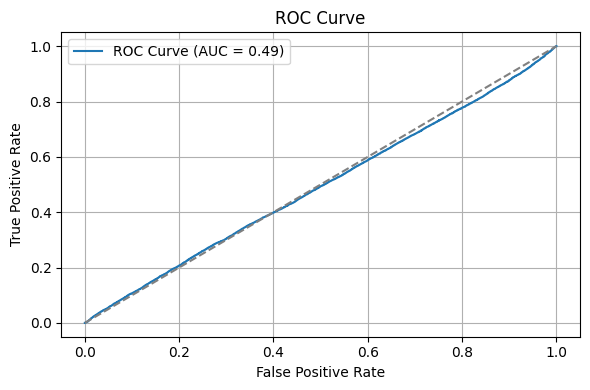

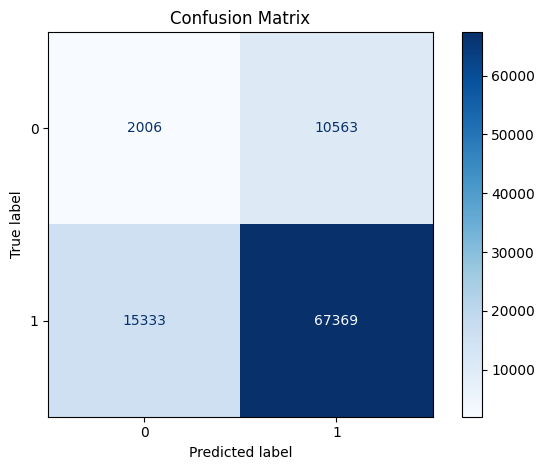

In [85]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve
)
import matplotlib.pyplot as plt

# 0. Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

all_preds = []
all_probs = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in new_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        outputs = model(X_batch)
        probs = torch.sigmoid(outputs).squeeze()

        preds = (probs >= 0.55)
        
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_targets.extend(y_batch.cpu().numpy())


# Convert to numpy arrays
y_true = np.array(all_targets)
y_pred = np.array(all_preds)
y_prob = np.array(all_probs)

# 10. Compute metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_true, y_prob)

print("\n📊 Evaluation Metrics:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")

# 11. Plot ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_prob)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 12. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


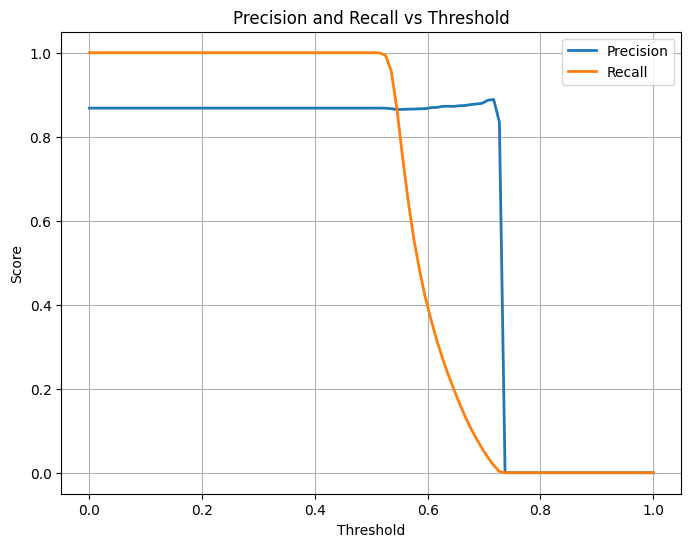

In [86]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score

def plot_precision_recall_vs_threshold(y_true, y_probs):
    thresholds = np.linspace(0, 1, 100)
    precisions = []
    recalls = []

    for t in thresholds:
        y_pred = (y_probs >= t).astype(float)
        precisions.append(precision_score(y_true, y_pred, zero_division=0))
        recalls.append(recall_score(y_true, y_pred))

    plt.figure(figsize=(8, 6))
    plt.plot(thresholds, precisions, label="Precision", linewidth=2)
    plt.plot(thresholds, recalls, label="Recall", linewidth=2)
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.title("Precision and Recall vs Threshold")
    plt.legend()
    plt.grid(True)
    plt.show()

# After evaluating the model and collecting all_probs and all_targets
# make sure these are available as numpy arrays:
# all_probs = np.array(all_probs)
# all_targets = np.array(all_targets)

plot_precision_recall_vs_threshold(all_targets, all_probs)



📊 Evaluation Metrics:
Accuracy : 0.7308
Precision: 0.8654
Recall   : 0.8170
F1 Score : 0.8405
ROC AUC  : 0.4938


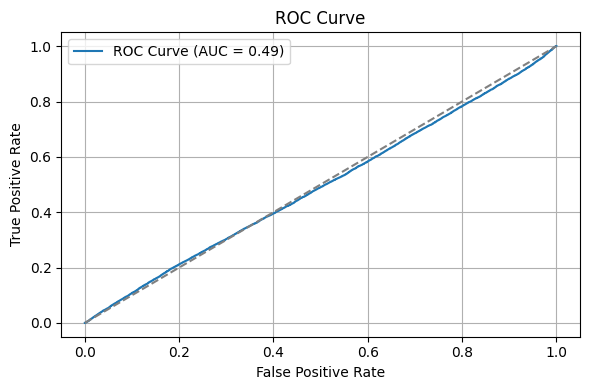

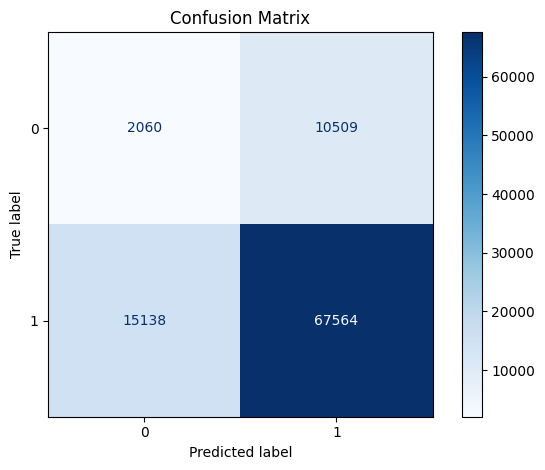

In [89]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve
)
import matplotlib.pyplot as plt

# 0. Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

all_preds = []
all_probs = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in new_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        outputs = model(X_batch)
        probs = outputs

        preds = (probs >= 0.2)
        
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_targets.extend(y_batch.cpu().numpy())


# Convert to numpy arrays
y_true = np.array(all_targets)
y_pred = np.array(all_preds)
y_prob = np.array(all_probs)

# 10. Compute metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_true, y_prob)

print("\n📊 Evaluation Metrics:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")

# 11. Plot ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_prob)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 12. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


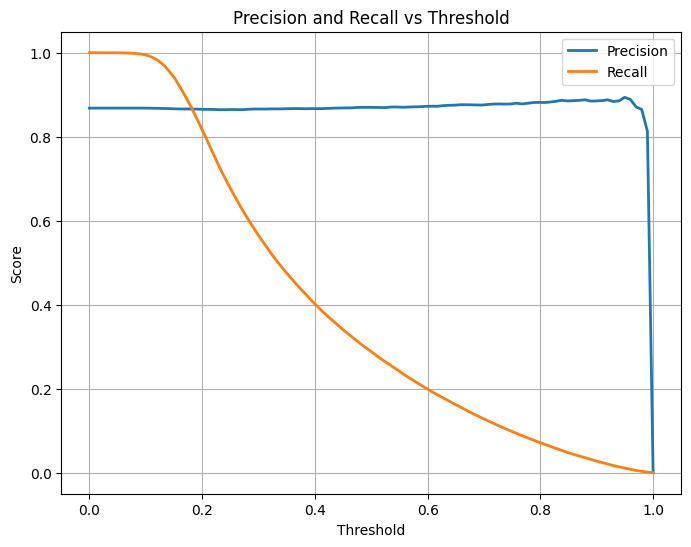

In [88]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score

def plot_precision_recall_vs_threshold(y_true, y_probs):
    thresholds = np.linspace(0, 1, 100)
    precisions = []
    recalls = []

    for t in thresholds:
        y_pred = (y_probs >= t).astype(float)
        precisions.append(precision_score(y_true, y_pred, zero_division=0))
        recalls.append(recall_score(y_true, y_pred))

    plt.figure(figsize=(8, 6))
    plt.plot(thresholds, precisions, label="Precision", linewidth=2)
    plt.plot(thresholds, recalls, label="Recall", linewidth=2)
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.title("Precision and Recall vs Threshold")
    plt.legend()
    plt.grid(True)
    plt.show()

# After evaluating the model and collecting all_probs and all_targets
# make sure these are available as numpy arrays:
# all_probs = np.array(all_probs)
# all_targets = np.array(all_targets)

plot_precision_recall_vs_threshold(all_targets, all_probs)
